In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib

In [3]:
df = pd.read_csv('청년정책목록_전체.csv', encoding='utf-8')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3458 entries, 0 to 3457
Data columns (total 60 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plcyNo             3458 non-null   object 
 1   bscPlanCycl        3458 non-null   int64  
 2   bscPlanPlcyWayNo   3458 non-null   int64  
 3   bscPlanFcsAsmtNo   3458 non-null   int64  
 4   bscPlanAsmtNo      3458 non-null   int64  
 5   pvsnInstGroupCd    3458 non-null   int64  
 6   plcyPvsnMthdCd     623 non-null    float64
 7   plcyAprvSttsCd     3458 non-null   int64  
 8   plcyNm             3458 non-null   object 
 9   plcyKywdNm         956 non-null    object 
 10  plcyExplnCn        3458 non-null   object 
 11  lclsfNm            3421 non-null   object 
 12  mclsfNm            3421 non-null   object 
 13  plcySprtCn         3458 non-null   object 
 14  sprvsnInstCd       2464 non-null   object 
 15  sprvsnInstCdNm     3440 non-null   object 
 16  sprvsnInstPicNm    766 n

In [4]:
# 정책번호
# 필요없는 컬럼
df['plcyNo']

# plcyNo 중복 데이터 확인
print(f"전체 데이터 수: {len(df)}")
print(f"고유한 plcyNo 수: {df['plcyNo'].nunique()}")

# 중복된 plcyNo 있는지 확인
duplicates = df['plcyNo'].duplicated().sum()
print(f"중복된 plcyNo 개수: {duplicates}")

# 중복된 plcyNo가 있다면 어떤 번호가 중복되었는지 확인
if duplicates > 0:
    duplicate_values = df[df['plcyNo'].duplicated(keep=False)].sort_values('plcyNo')
    print("중복된 plcyNo 값:")
    display(duplicate_values[['plcyNo']])

전체 데이터 수: 3458
고유한 plcyNo 수: 3458
중복된 plcyNo 개수: 0


# 정책

In [39]:
# 정책제공방법코드, 정책승인상태코드, 정책명, 정책키워드명, 정책설명내용, 정책지원내용, 정책신청방법내용
df[['plcyPvsnMthdCd', 'plcyAprvSttsCd', 'plcyNm', 'plcyKywdNm', 'plcyExplnCn', 'plcySprtCn', 'plcyAplyMthdCn']].head(5)


,plcyPvsnMthdCd,plcyAprvSttsCd,plcyNm,plcyKywdNm,plcyExplnCn,plcySprtCn,plcyAplyMthdCn
0,42013.0,44002,주거안정장학금,"보조금,교육지원",원거리 대학 진학으로 인해 주거 관련 비용 부담이 큰 저소득 대학생을 대상으로 주거...,"□ 지원금액: 월 최대 20만 원\n※ 단, 방학 중(7~8월, 1~2월)에는 지원...",□ 2학기 신청일정: 2025. 5. 23.(금) 9시 ~ 6. 23.(월) 18시...
1,42010.0,44002,부산 청년돌봄이음,바우처,고립·은둔 청년 및 가족돌봄 청(소)년 지원,"1. 청년 돌봄이음 시범사업(제공기관 : 종합사회복지관) : 초기상담, 성장 계획 ...",부산사회서비스원 홈페이지온라인 신청\n○ 고립은둔 청년 지원 신청 : https:/...
2,42005.0,44002,서울 청년 마음건강 지원사업,맞춤형상담서비스,우울·불안 등 정서적 어려움을 겪는 청년의 마음건강 회복,ㅇ (사업 내용) 2단계 선별검사로 과학적 진단을 통한 맞춤형 상담 지원\n ...,"총 4차(1월, 4월, 6월, 9월)에 걸쳐 참여자를 모집하며, 연도내 중복참여는 ..."
3,42005.0,44002,희망두배 청년통장,금리혜택,"학자금 대출, 주거비, 비정규직 취업 등으로 어려움을 겪고 있는 청년의 자립지원을 ...",□ 본인저축액 : 월 15만원\n□ 매칭지원액 : 본인저축액과 동일한 금액 매월 적...,□ 신청기간 : 2025. 6. 9.(월) ~ 6. 20.(금) 18:00 ※ 신청...
4,42002.0,44002,서울 영테크,맞춤형상담서비스,청년 금융교육 및 재무상담을 통한 경제적 자립 지원,"무료 재무상담(대면, 비대면) 및 금융교육, 커뮤니티 운영\nㅇ (재무상담) 재무진...",NaN


In [17]:
# 정책제공방법코드
df['plcyPvsnMthdCd'].value_counts()

plcyPvsnMthdCd
42006.0    165
42013.0    163
42002.0    141
42004.0     46
42001.0     33
42010.0     31
42005.0     24
42011.0      9
42003.0      5
42007.0      4
42012.0      1
42008.0      1
Name: count, dtype: int64

In [ ]:
# 정책승인상태코드
# 필요없는 컬럼
df['plcyAprvSttsCd'].value_counts()

plcyAprvSttsCd
44002    3458
Name: count, dtype: int64

In [20]:
# 정책키워드명
# ,로 구분된 키워드 분리작업 필요


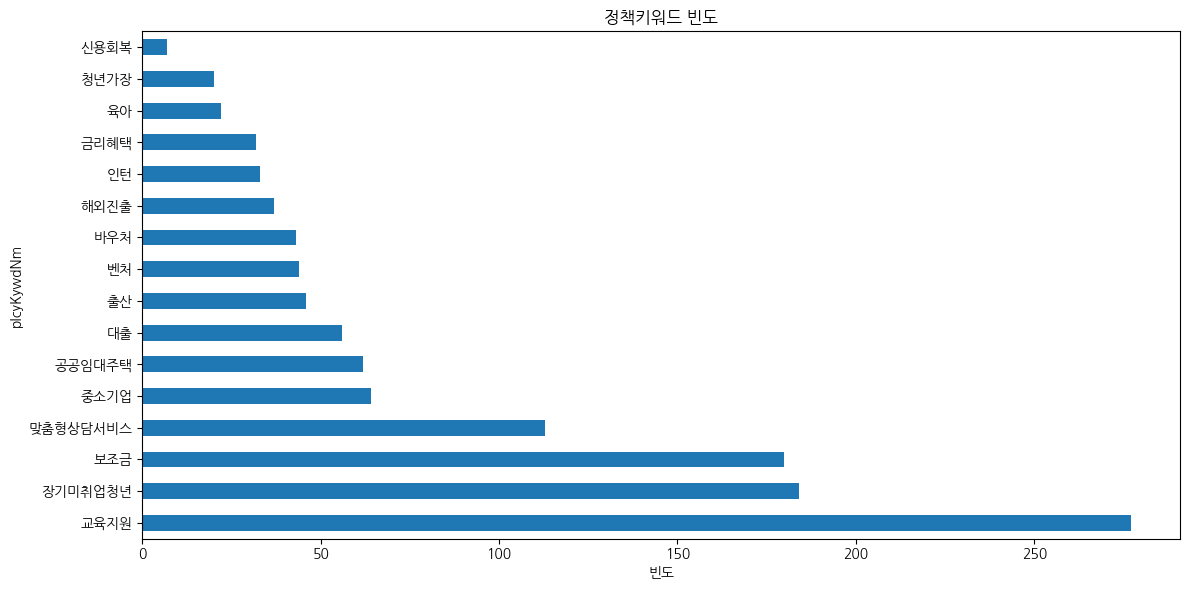

In [25]:
# 쉼표로 분리하여 키워드 카운트
all_keywords = df['plcyKywdNm'].dropna().str.split(',').explode().str.strip()
keyword_counts = all_keywords.value_counts()

# 키워드 총 16개
plt.figure(figsize=(12, 6))
keyword_counts.plot(kind='barh')
plt.title('정책키워드 빈도')
plt.xlabel('빈도')
plt.tight_layout()
plt.show()

# 분류

In [44]:
# 정책대분류명, 정책중분류명
df[['lclsfNm', 'mclsfNm']]

,lclsfNm,mclsfNm
0,교육,교육비지원
1,복지문화,취약계층 및 금융지원
2,복지문화,건강
3,복지문화,취약계층 및 금융지원
4,복지문화,취약계층 및 금융지원
...,...,...
3453,"복지문화,복지문화","취약계층 및 금융지원,건강"
3454,"주거,주거","주택 및 거주지,전월세 및 주거급여 지원"
3455,"일자리,일자리","취업,창업"
3456,"일자리,교육,복지문화","취업,미래역량강화,취약계층 및 금융지원"


In [26]:
# 정책대분류명, 중분류명 ,로 구분된 키워드 분리작업 필요

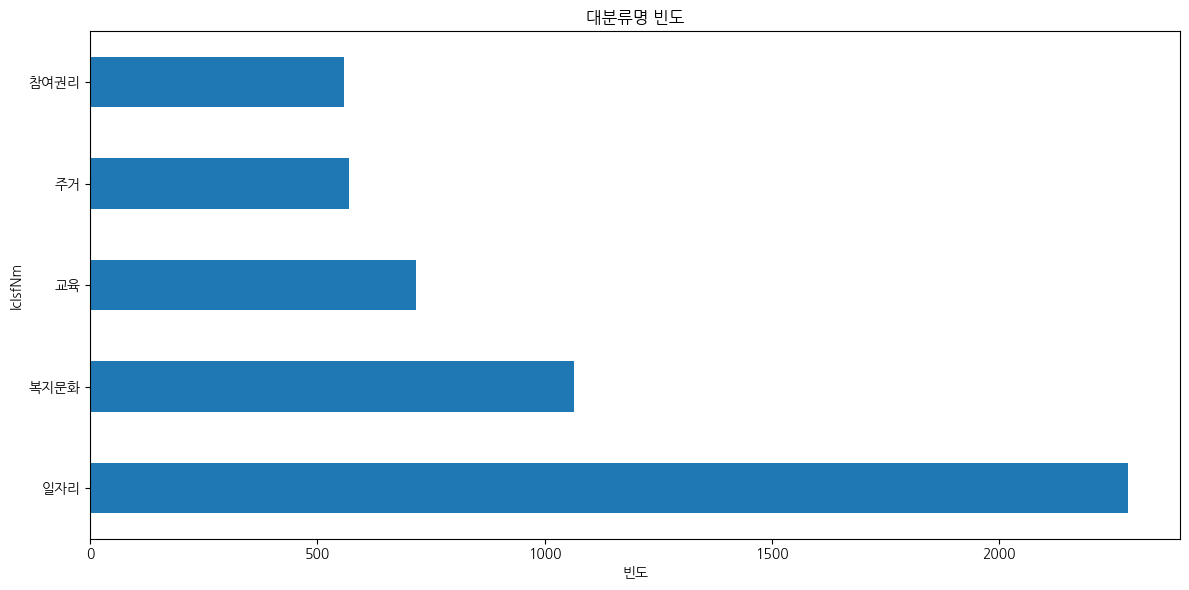

In [ ]:
# 쉼표로 분리하여 대분류명 카운트
all_keywords = df['lclsfNm'].dropna().str.split(',').explode().str.strip()
keyword_counts = all_keywords.value_counts()

# 시각화
plt.figure(figsize=(12, 6))
keyword_counts.head(15).plot(kind='barh')
plt.title('대분류명 빈도')
plt.xlabel('빈도')
plt.tight_layout()
plt.show()

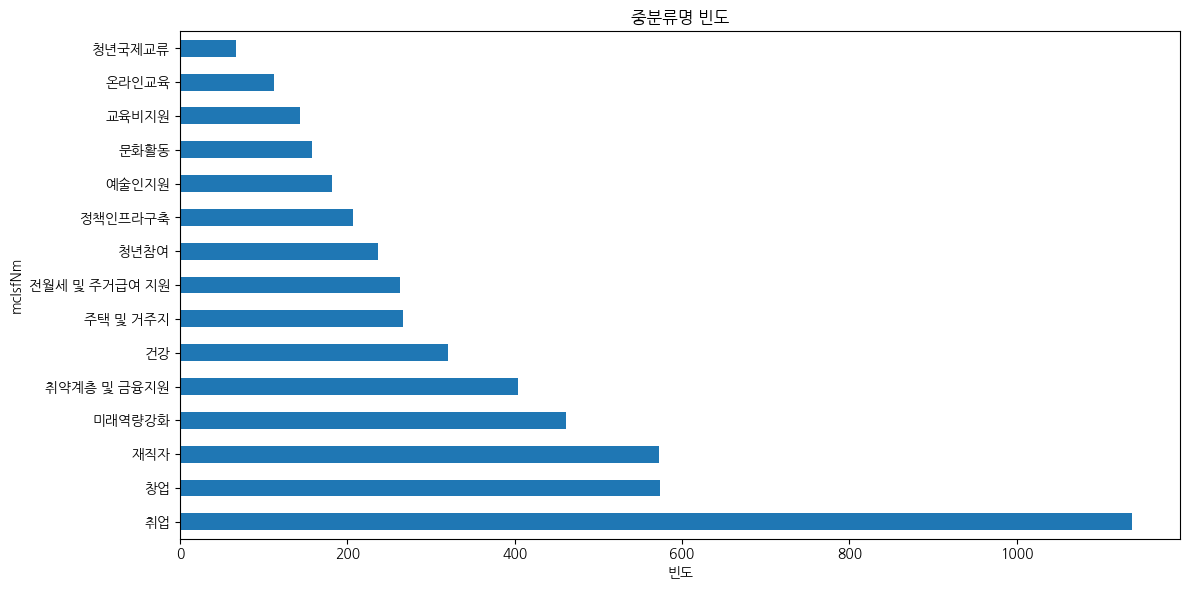

In [29]:
# 쉼표로 분리하여 중분류명 카운트
all_keywords = df['mclsfNm'].dropna().str.split(',').explode().str.strip()
keyword_counts = all_keywords.value_counts()

# 상위 15개 시각화
plt.figure(figsize=(12, 6))
keyword_counts.head(15).plot(kind='barh')
plt.title('중분류명 빈도')
plt.xlabel('빈도')
plt.tight_layout()
plt.show()

In [ ]:
# 정책키워드와 중분류명의 데이터가 비슷한 성격을 가짐

In [6]:
# 조건을 하나만 적용하여 확인
취업_df = df[df['mclsfNm'].str.contains('취업', na=False)]
교육지원_df = df[df['plcyKywdNm'].str.contains('교육지원', na=False)]

print(f"중분류명에 '취업'이 포함된 데이터 수: {len(취업_df)}")
print(f"정책키워드명에 '교육지원'이 포함된 데이터 수: {len(교육지원_df)}")

중분류명에 '취업'이 포함된 데이터 수: 1138
정책키워드명에 '교육지원'이 포함된 데이터 수: 277


In [ ]:
# 중분류명에 '취업'이 포함되고 정책키워드명에 '교육지원'이 포함된 데이터 필터링
filtered_df = df[
    df['mclsfNm'].str.contains('취업', na=False) & 
    df['plcyKywdNm'].str.contains('교육지원', na=False)
]

# 결과 확인
print(f"필터링된 데이터 수: {len(filtered_df)}")

# 필터링된 데이터의 일부 컬럼 보기
if len(filtered_df) > 0:
    display(filtered_df[['plcyNm', 'mclsfNm', 'plcyKywdNm', 'plcyExplnCn']].head())
else:
    print("해당 조건을 만족하는 데이터가 없습니다.")
    
# 정책지원내용 확인 (첫 번째 항목)
if len(filtered_df) > 0:
    print("\n첫 번째 정책의 지원내용:")
    print(filtered_df['plcySprtCn'].iloc[0])

필터링된 데이터 수: 116


,plcyNm,mclsfNm,plcyKywdNm,plcyExplnCn
12,부산지역인재 장학금 및 취업장려금,"취업,미래역량강화","교육지원,보조금","부산지역 대학의 IT 및 상경 분야 대학생 3,4학년(전문대학 2학년) 대상으로 생..."
25,속초시 청년 취업자격증 취득 응시료 지원사업,취업,교육지원,취업난으로 어려움을 겪는 청년들에게 취업 준비 시 필요한 자격증 응시료를 지원하여 ...
26,공공기관 맞춤형 취업지원사업,취업,교육지원,울산경남 지역 공공기관의 울산 청년 기업기회 확대를 위해 공공기관 취업을 준비하는 ...
27,청년 자격증 응시료 지원사업,취업,"교육지원,보조금",취업 및 이직을 위한 능동적 구직활동을 하는 청년들에게 자격증 응시가 확인 될 경우...
36,"대학생 지역인재육성지원금 지원(1,2학기)","취업,미래역량강화",교육지원,지역인재 양성을 위해 우수학생 및 예체능 등 다양한 분야의 인재를 발굴 지원하여 학...



첫 번째 정책의 지원내용:
○ 지원대상 : 부산지역 대학의 IT 및 상경 분야 대학생 3,4학년(전문대학 2학년)
○ 지원자격
    - 직전학기 12학점 이상 이수 및 성적 3.5이상(4.5만점 기준)
    - 한국장학재단 학자금 지원구간의 소득 9분위 이하인 자
○ 지원내용 
    - 생활장학금 (1인당 150만원)
    - 생활장학금 수혜자 중 졸업 후 지역기업에 입사하여 12개월 이상 취업을 유지하는 경우 취업장려금 추가 지급(1회 150만원)


In [9]:
# 정책키워드명에 교육지원인 데이터 중 중분류명이 취업인 데이터인 비율
len(filtered_df) / len(교육지원_df) * 100

41.87725631768953

# 신청기간구분코드

신청기간구분코드(aplyPrdSeCd) 빈도:
aplyPrdSeCd
57001    2320
57003     847
57002     291
Name: count, dtype: int64

결측치 개수: 0


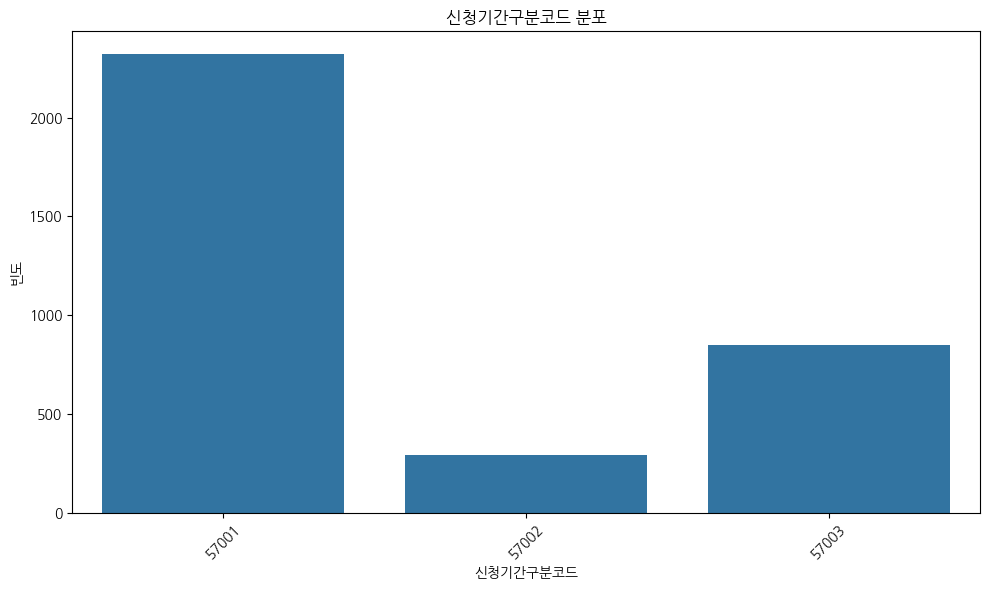

In [46]:
# 신청기간구분코드 빈도 분석
print("신청기간구분코드(aplyPrdSeCd) 빈도:")
aplyPrdSeCd_counts = df['aplyPrdSeCd'].value_counts()
print(aplyPrdSeCd_counts)
print(f"\n결측치 개수: {df['aplyPrdSeCd'].isnull().sum()}")

# 신청기간구분코드 시각화
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='aplyPrdSeCd')
plt.title('신청기간구분코드 분포')
plt.xlabel('신청기간구분코드')
plt.ylabel('빈도')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()